# Notebook 3: Hồi quy Phi tuyến

## Đọc dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import time
from utils import (
    load_bike_data,
    evaluate_model,
    plot_sklearn_learning_curve_wrapper,
    plot_learning_curve_data_size,
)

(
    train_df,
    features_to_drop,
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    X_test_scaled,
    y_test,
    X_train_b,
    X_val_b,
    X_test_b,
) = load_bike_data()

## 3. Hàm Cơ Sở Phi Tuyến (Nonlinear Basis Functions)
Lựa chọn: Polynomial, Gaussian RBF, B-Spline. Phân tích Ablation và Interaction.


=== 4.1. Áp dụng 3 Loại Hàm Cơ Sở ===
[Ridge + Polynomial (deg=2)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 14111.80 ± 7584.45
  - CV_RMSE (Mean ± Std): 114.75 ± 30.71
  - CV_MAE (Mean ± Std): 90.96 ± 24.66
  - CV_R2 (Mean ± Std): 0.3269 ± 0.2675
  - Val MSE: 25705.5956
  - Val RMSE: 160.3296
  - Val MAE: 125.4450
  - Val R2: 0.4635
  - Test MSE: 32532.7643
  - Test RMSE: 180.3684
  - Test MAE: 124.8291
  - Test R2: 0.3308
[Ridge + Gaussian RBF (n=100)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 11297.39 ± 4538.71
  - CV_RMSE (Mean ± Std): 104.09 ± 21.49
  - CV_MAE (Mean ± Std): 79.03 ± 13.92
  - CV_R2 (Mean ± Std): 0.3957 ± 0.3280
  - Val MSE: 16030.5311
  - Val RMSE: 126.6117
  - Val MAE: 93.3372
  - Val R2: 0.6654
  - Test MSE: 28928.9685
  - Test RMSE: 170.0852
  - Test MAE: 117.5446
  - Test R2: 0.4049
[Ridge + B-Spline (knots=4, deg=3)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 13590.76 ± 7127.21
  - CV_RMSE (Mean ± Std): 112.95 ± 28.88
  - CV_MAE (Mean ± Std): 86.76 ± 22.88


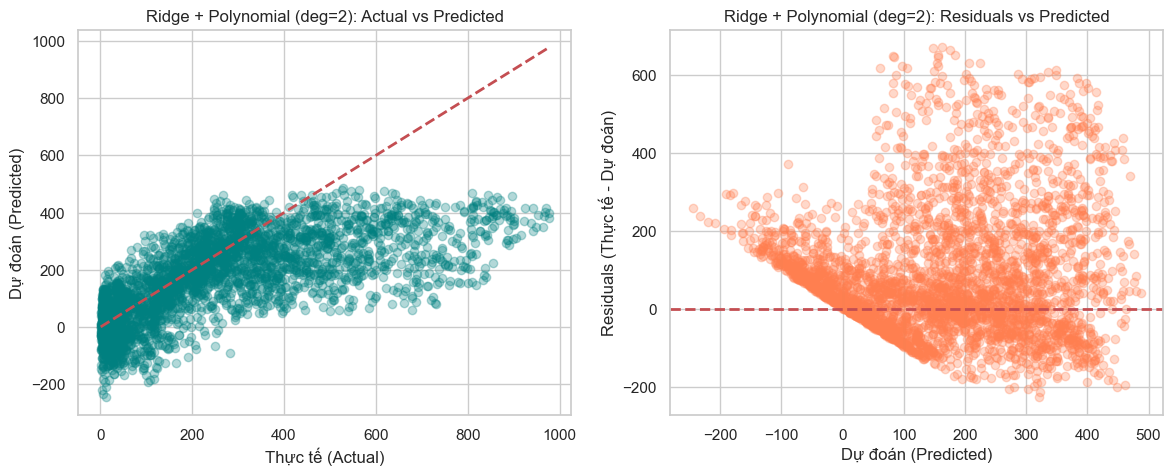

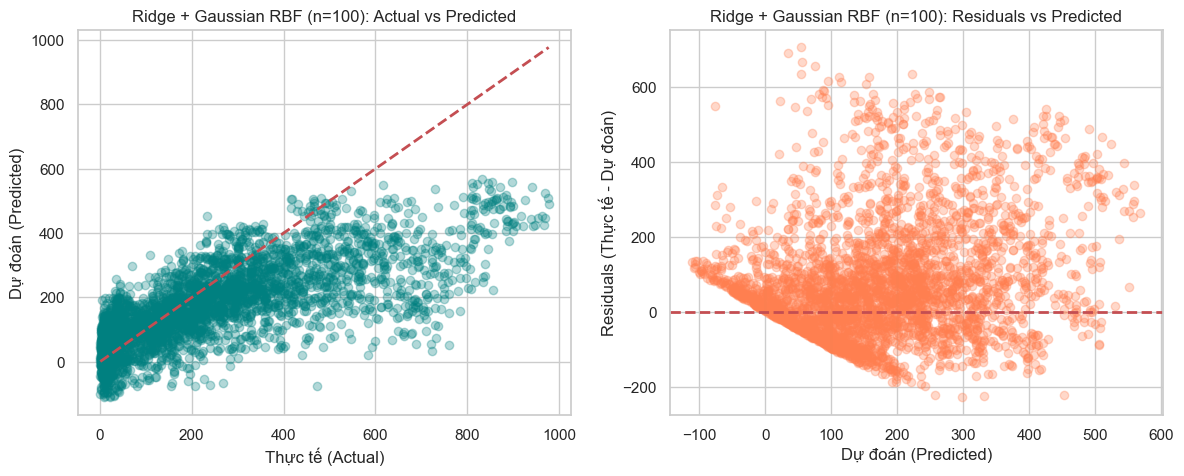

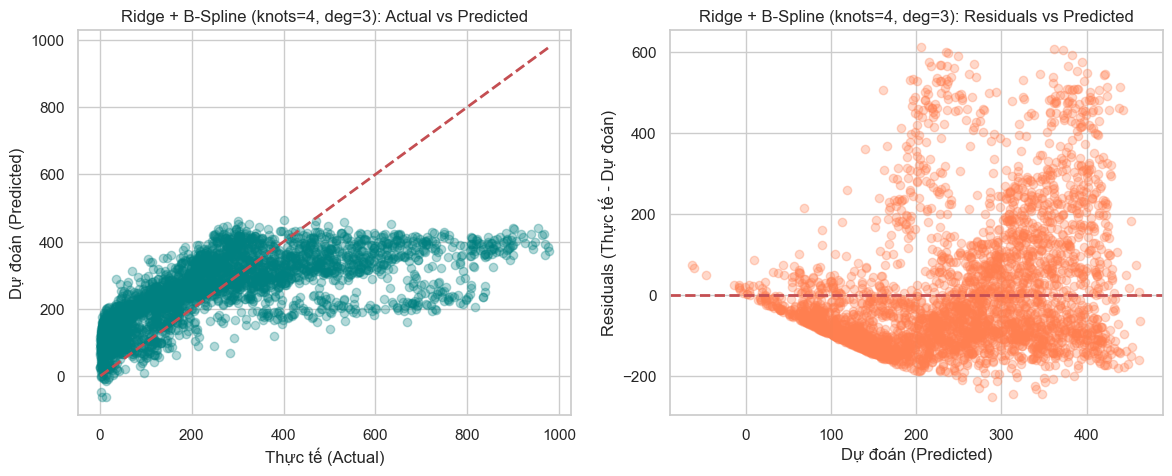

In [2]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

# Bọc Ridge với Sklearn để tiện dùng Transformation Pipelines
ridge_alpha = best_lam_ridge if "best_lam_ridge" in globals() else 10.0

print("\n" + "=" * 60)
print("=== 4.1. Áp dụng 3 Loại Hàm Cơ Sở ===")
print("=" * 60)


def fit_pred_sk_ridge(X_tr, y_tr, X_val):
    model = Ridge(alpha=ridge_alpha)
    model.fit(X_tr, y_tr)
    return model.predict(X_val), model


# 1. Polynomial
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)
poly_model = evaluate_model(
    "Ridge + Polynomial (deg=2)",
    fit_pred_sk_ridge,
    X_train_poly,
    y_train,
    X_test_poly,
    y_test,
    X_val_poly,
    y_val,
)

# 2. Gaussian RBF Features
rbf = RBFSampler(gamma=0.1, random_state=42, n_components=100)
X_train_rbf = rbf.fit_transform(X_train_scaled)
X_val_rbf = rbf.transform(X_val_scaled)
X_test_rbf = rbf.transform(X_test_scaled)
_ = evaluate_model(
    "Ridge + Gaussian RBF (n=100)",
    fit_pred_sk_ridge,
    X_train_rbf,
    y_train,
    X_test_rbf,
    y_test,
    X_val_rbf,
    y_val,
)

# 3. SplineTransformer (B-Splines)
spline = SplineTransformer(n_knots=4, degree=3, include_bias=False)
X_train_spline = spline.fit_transform(X_train_scaled)
X_val_spline = spline.transform(X_val_scaled)
X_test_spline = spline.transform(X_test_scaled)
_ = evaluate_model(
    "Ridge + B-Spline (knots=4, deg=3)",
    fit_pred_sk_ridge,
    X_train_spline,
    y_train,
    X_test_spline,
    y_test,
    X_val_spline,
    y_val,
)

### 3.1 Vẽ Validation Curve theo độ phức tạp

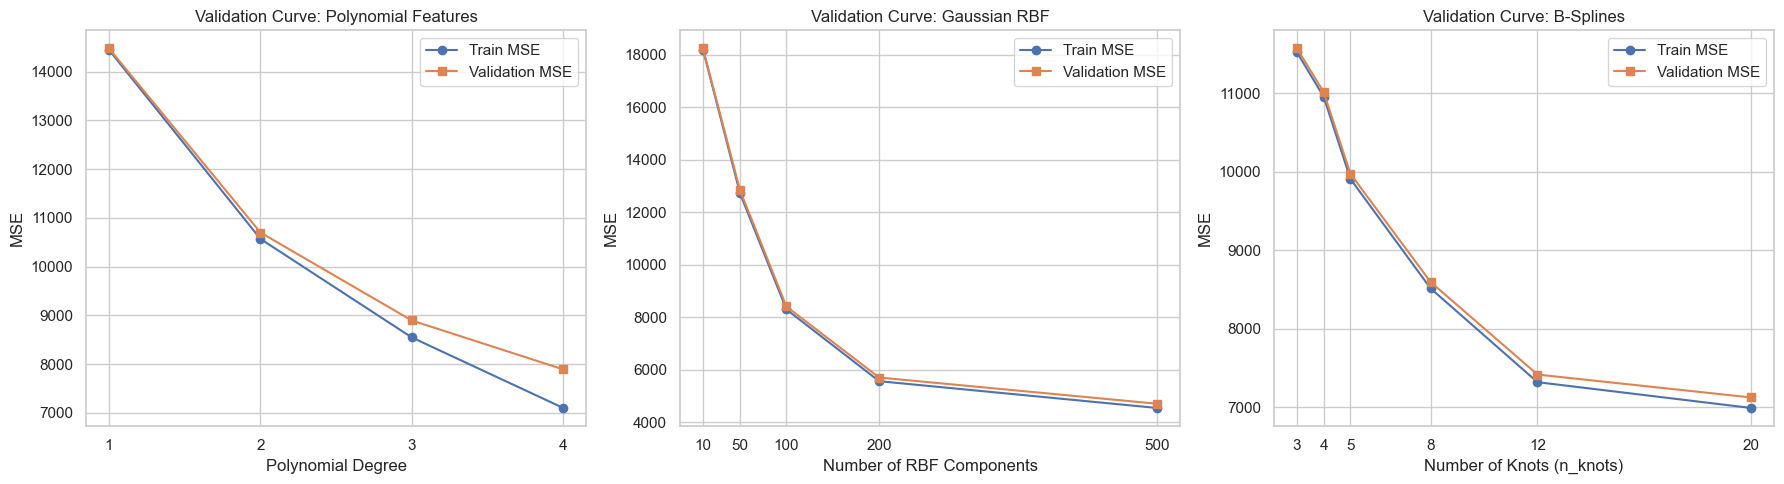

In [3]:
# Validation Curve: Bậc đa thức (Degree)
degrees = [1, 2, 3, 4]
poly_train_errs, poly_val_errs = [], []
kf_4 = KFold(n_splits=5, shuffle=True, random_state=42)

for d in degrees:
    poly_d = PolynomialFeatures(degree=d, include_bias=False)
    X_poly_d = poly_d.fit_transform(X_train_scaled)

    t_err, v_err = [], []
    for tr_idx, val_idx in kf_4.split(X_poly_d):
        m = Ridge(alpha=ridge_alpha).fit(X_poly_d[tr_idx], y_train[tr_idx])
        t_err.append(mean_squared_error(y_train[tr_idx], m.predict(X_poly_d[tr_idx])))
        v_err.append(mean_squared_error(y_train[val_idx], m.predict(X_poly_d[val_idx])))

    poly_train_errs.append(np.mean(t_err))
    poly_val_errs.append(np.mean(v_err))

# Validation Curve: n_components (RBF)
n_comps = [10, 50, 100, 200, 500]
rbf_train_errs, rbf_val_errs = [], []

for n in n_comps:
    rbf_n = RBFSampler(gamma=0.1, n_components=n, random_state=42)
    X_rbf_n = rbf_n.fit_transform(X_train_scaled)

    t_err, v_err = [], []
    for tr_idx, val_idx in kf_4.split(X_rbf_n):
        m = Ridge(alpha=ridge_alpha).fit(X_rbf_n[tr_idx], y_train[tr_idx])
        t_err.append(mean_squared_error(y_train[tr_idx], m.predict(X_rbf_n[tr_idx])))
        v_err.append(mean_squared_error(y_train[val_idx], m.predict(X_rbf_n[val_idx])))

    rbf_train_errs.append(np.mean(t_err))
    rbf_val_errs.append(np.mean(v_err))

# Validation Curve: B-Spline (Số lượng knots)
knots_list = [3, 4, 5, 8, 12, 20]  # n_knots tối thiểu là 3 đối với degree=3
spline_train_errs, spline_val_errs = [], []

for k in knots_list:
    spline_k = SplineTransformer(n_knots=k, degree=3, include_bias=False)
    X_spline_k = spline_k.fit_transform(X_train_scaled)

    t_err, v_err = [], []
    for tr_idx, val_idx in kf_4.split(X_spline_k):
        m = Ridge(alpha=ridge_alpha).fit(X_spline_k[tr_idx], y_train[tr_idx])
        t_err.append(mean_squared_error(y_train[tr_idx], m.predict(X_spline_k[tr_idx])))
        v_err.append(
            mean_squared_error(y_train[val_idx], m.predict(X_spline_k[val_idx]))
        )

    spline_train_errs.append(np.mean(t_err))
    spline_val_errs.append(np.mean(v_err))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(degrees, poly_train_errs, label="Train MSE", marker="o")
axes[0].plot(degrees, poly_val_errs, label="Validation MSE", marker="s")
axes[0].set_xlabel("Polynomial Degree")
axes[0].set_ylabel("MSE")
axes[0].set_title("Validation Curve: Polynomial Features")
axes[0].set_xticks(degrees)
axes[0].legend()

axes[1].plot(n_comps, rbf_train_errs, label="Train MSE", marker="o")
axes[1].plot(n_comps, rbf_val_errs, label="Validation MSE", marker="s")
axes[1].set_xlabel("Number of RBF Components")
axes[1].set_ylabel("MSE")
axes[1].set_title("Validation Curve: Gaussian RBF")
axes[1].set_xticks(n_comps)
axes[1].legend()

axes[2].plot(knots_list, spline_train_errs, label="Train MSE", marker="o")
axes[2].plot(knots_list, spline_val_errs, label="Validation MSE", marker="s")
axes[2].set_xlabel("Number of Knots (n_knots)")
axes[2].set_ylabel("MSE")
axes[2].set_title("Validation Curve: B-Splines")
axes[2].set_xticks(knots_list)
axes[2].legend()

plt.tight_layout()
plt.show()

### 3.2 Ablation Study: Tính quan trọng của nhóm đặc trưng

In [4]:
print("\n" + "=" * 60)
print("=== 4.3. Ablation Study ===")
print("=" * 60)

feat_names = list(
    train_df.drop(columns=features_to_drop + ["cnt"], errors="ignore").columns
)

# Cấu hình Nhóm đặc trưng
groups = {
    "Weather/Environment": [
        f
        for f in feat_names
        if f in ["weathersit", "temp", "atemp", "hum", "windspeed"]
    ],
    "Time/Date": [f for f in feat_names if f in ["yr", "mnth", "hr"]],
    "Calendar/Events": [
        f for f in feat_names if f in ["season", "holiday", "weekday", "workingday"]
    ],
}

base_model = Ridge(alpha=ridge_alpha).fit(X_train_scaled, y_train)
base_mse = mean_squared_error(y_test, base_model.predict(X_test_scaled))
print(f"Balseline MSE (Full features): {base_mse:.4f}\n")

performance_drop = {}
for group_name, group_feats in groups.items():
    if not group_feats:
        continue

    drop_indices = [feat_names.index(f) for f in group_feats]
    keep_indices = [i for i in range(len(feat_names)) if i not in drop_indices]

    X_tr_ablated = X_train_scaled[:, keep_indices]
    X_test_ablated = X_test_scaled[:, keep_indices]

    abl_model = Ridge(alpha=ridge_alpha).fit(X_tr_ablated, y_train)
    abl_pred = abl_model.predict(X_test_ablated)
    abl_mse = mean_squared_error(y_test, abl_pred)

    diff = abl_mse - base_mse
    performance_drop[group_name] = diff
    print(f"Drop '{group_name}' -> MSE: {abl_mse:.4f} (Chênh lệch: +{diff:.4f})")

worst_group = max(performance_drop, key=performance_drop.get)
print(f"\n=> Nhóm đặc trưng ảnh hưởng nghiêm trọng nhất khi thiếu vắng: {worst_group}")


=== 4.3. Ablation Study ===
Balseline MSE (Full features): 33724.4270

Drop 'Weather/Environment' -> MSE: 40760.4133 (Chênh lệch: +7035.9863)
Drop 'Time/Date' -> MSE: 44745.7356 (Chênh lệch: +11021.3086)
Drop 'Calendar/Events' -> MSE: 34401.1278 (Chênh lệch: +676.7008)

=> Nhóm đặc trưng ảnh hưởng nghiêm trọng nhất khi thiếu vắng: Time/Date


### 3.3 Phân tích Cơ chế Tương Tác ($x_i x_j$)

#### Interaction Only


=== 4.4. Phân tích Hiệu ứng Tương tác (Interaction Only) ===
[Ridge + All Interactions] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17058.34 ± 9644.48
  - CV_RMSE (Mean ± Std): 125.14 ± 37.39
  - CV_MAE (Mean ± Std): 97.19 ± 31.43
  - CV_R2 (Mean ± Std): 0.2537 ± 0.1123
  - Val MSE: 30445.5586
  - Val RMSE: 174.4866
  - Val MAE: 134.8400
  - Val R2: 0.3646
  - Test MSE: 38850.7128
  - Test RMSE: 197.1058
  - Test MAE: 135.0338
  - Test R2: 0.2008


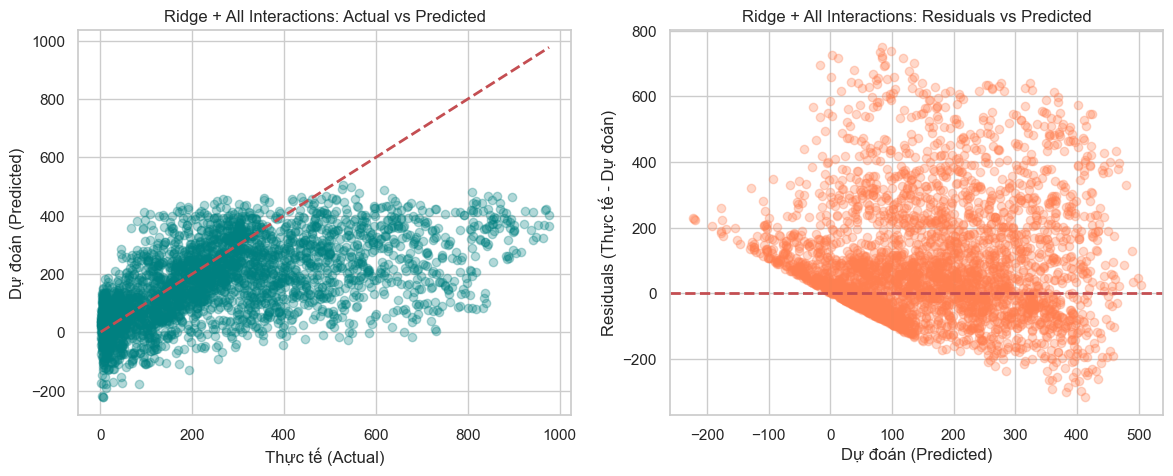

In [5]:
print("\n" + "=" * 60)
print("=== 4.4. Phân tích Hiệu ứng Tương tác (Interaction Only) ===")
print("=" * 60)

# Cấu hình PolynomialFeatures chỉ tạo tương tác chéo (không có bình phương)
poly_inter = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_inter = poly_inter.fit_transform(X_train_scaled)
X_val_inter = poly_inter.transform(X_val_scaled)
X_test_inter = poly_inter.transform(X_test_scaled)

inter_model = evaluate_model(
    "Ridge + All Interactions",
    fit_pred_sk_ridge,
    X_train_inter,
    y_train,
    X_test_inter,
    y_test,
    X_val_inter,
    y_val,
)

#### Phân tích Tương tác Thủ công (Domain Knowledge)
Bổ sung một vài biến tương tác cụ thể nhằm tối ưu kích thước mô hình thay vì tính tất cả.


=== 4.5. Phân tích Tương tác Thủ công (Tuỳ chỉnh) ===
[Ridge + Custom Interactions (temp*hum, hr*work)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17407.29 ± 9387.20
  - CV_RMSE (Mean ± Std): 127.13 ± 35.29
  - CV_MAE (Mean ± Std): 98.31 ± 29.92
  - CV_R2 (Mean ± Std): 0.1980 ± 0.2384
  - Val MSE: 32947.0258
  - Val RMSE: 181.5132
  - Val MAE: 146.7694
  - Val R2: 0.3124
  - Test MSE: 33441.1202
  - Test RMSE: 182.8691
  - Test MAE: 138.3650
  - Test R2: 0.3121


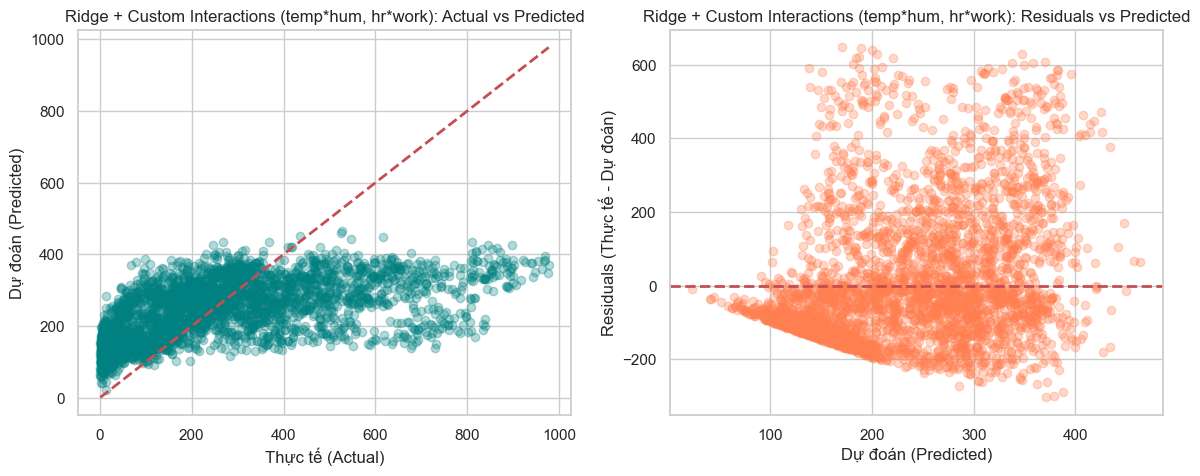

In [6]:
print("\n" + "=" * 60)
print("=== 4.5. Phân tích Tương tác Thủ công (Tuỳ chỉnh) ===")
print("=" * 60)
idx_temp = feat_names.index("temp")
idx_hum = feat_names.index("hum")
idx_hr = feat_names.index("hr")
idx_work = feat_names.index("workingday")

# Nối thêm tích của (temp * hum) và (hr * workingday) vào data gốc
X_train_custom = np.c_[
    X_train_scaled,
    X_train_scaled[:, idx_temp] * X_train_scaled[:, idx_hum],
    X_train_scaled[:, idx_hr] * X_train_scaled[:, idx_work],
]
X_val_custom = np.c_[
    X_val_scaled,
    X_val_scaled[:, idx_temp] * X_val_scaled[:, idx_hum],
    X_val_scaled[:, idx_hr] * X_val_scaled[:, idx_work],
]
X_test_custom = np.c_[
    X_test_scaled,
    X_test_scaled[:, idx_temp] * X_test_scaled[:, idx_hum],
    X_test_scaled[:, idx_hr] * X_test_scaled[:, idx_work],
]

custom_model = evaluate_model(
    "Ridge + Custom Interactions (temp*hum, hr*work)",
    fit_pred_sk_ridge,
    X_train_custom,
    y_train,
    X_test_custom,
    y_test,
    X_val_custom,
    y_val,
)

#### So sánh hiệu quả của các mô hình

In [7]:
print("\nSO SÁNH MỨC ĐỘ HIỆU QUẢ CỦA TƯƠNG TÁC:")
print(f"MSE Gốc Linear                    : {base_mse:.4f}")
print(
    f"MSE Gốc + 2 Tương tác (Tuỳ chỉnh) : {mean_squared_error(y_test, custom_model.predict(X_test_custom)):.4f}"
)
print(
    f"MSE Gốc + TẤT CẢ Tương tác chéo   : {mean_squared_error(y_test, inter_model.predict(X_test_inter)):.4f}"
)
print(
    f"MSE Bậc 2 Đầy đủ (Tương tác + x^2): {mean_squared_error(y_test, poly_model.predict(X_test_poly)):.4f}"
)


SO SÁNH MỨC ĐỘ HIỆU QUẢ CỦA TƯƠNG TÁC:
MSE Gốc Linear                    : 33724.4270
MSE Gốc + 2 Tương tác (Tuỳ chỉnh) : 33441.1202
MSE Gốc + TẤT CẢ Tương tác chéo   : 38850.7128
MSE Bậc 2 Đầy đủ (Tương tác + x^2): 32532.7643


**Nhận xét**:

- Việc thêm một số tương tác có chọn lọc giúp cải thiện nhẹ hiệu năng so với mô hình tuyến tính gốc.
- Tuy nhiên, thêm toàn bộ tương tác chéo lại làm MSE tăng mạnh → dấu hiệu overfitting / nhiễu.
- Mô hình đa thức bậc 2 đầy đủ cho kết quả tốt nhất, cho thấy dữ liệu có quan hệ phi tuyến rõ ràng.

**Kết luận:**
Việc bổ sung biến tương tác chỉ hiệu quả khi được kiểm soát hợp lý; thêm quá nhiều đặc trưng dễ làm mô hình kém tổng quát.